In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# The dataset slug is 'birdy654/cifake-real-and-ai-generated-synthetic-images'
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images


Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:07<00:00, 14.3MB/s]



In [ ]:
!unzip cifake-real-and-ai-generated-synthetic-images.zip -d cifake_data

Streaming output truncated to the last 5000 lines.
  inflating: cifake_data/train/REAL/4500 (10).jpg  
  inflating: cifake_data/train/REAL/4500 (2).jpg  
  inflating: cifake_data/train/REAL/4500 (3).jpg  
  inflating: cifake_data/train/REAL/4500 (4).jpg  
  inflating: cifake_data/train/REAL/4500 (5).jpg  
  inflating: cifake_data/train/REAL/4500 (6).jpg  
  inflating: cifake_data/train/REAL/4500 (7).jpg  
  inflating: cifake_data/train/REAL/4500 (8).jpg  
  inflating: cifake_data/train/REAL/4500 (9).jpg  
  inflating: cifake_data/train/REAL/4500.jpg  
  inflating: cifake_data/train/REAL/4501 (10).jpg  
  inflating: cifake_data/train/REAL/4501 (2).jpg  
  inflating: cifake_data/train/REAL/4501 (3).jpg  
  inflating: cifake_data/train/REAL/4501 (4).jpg  
  inflating: cifake_data/train/REAL/4501 (5).jpg  
  inflating: cifake_data/train/REAL/4501 (6).jpg  
  inflating: cifake_data/train/REAL/4501 (7).jpg  
  inflating: cifake_data/train/REAL/4501 (8).jpg  
  inflating: cifake_data/train/RE

In [ ]:
DATA_ROOT = "cifake_data/"

In [ ]:
# Cell 1: Setup and Imports (Mobile-SSP for CIFAKE)
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import random
import numpy as np
from datetime import datetime
from PIL import ImageFile
import matplotlib.pyplot as plt
ImageFile.LOAD_TRUNCATED_IMAGES = True
DATA_ROOT = "cifake_data/"


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


opt_gpu_id = '0'

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print(f"Environment ready for CIFAKE Mobile-SSP training.")

Using device: cuda
Environment ready for CIFAKE Mobile-SSP training.


In [ ]:
import random
import numpy as np

def set_random_seed(seed=42):
    """Sets the random seed for reproducibility across ResNet and MobileNet runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

def poly_lr(optimizer, initial_lr, epoch, total_epochs, power=0.9):
    """Polynomial Learning Rate Scheduler used to prevent overfitting in MobileNet."""
    cur_lr = initial_lr * (1 - epoch / total_epochs) ** power
    for param_group in optimizer.param_groups:
        param_group['lr'] = cur_lr
    return cur_lr

class bceLoss(nn.Module):
    def __init__(self):
        super(bceLoss, self).__init__()
        self.loss = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        return self.loss(pred, target.float())

set_random_seed()

Random seed set to 42


In [ ]:

from torchvision import models

class SSP_MobileNet(nn.Module):
    def __init__(self):
        super(SSP_MobileNet, self).__init__()

        self.backbone = models.mobilenet_v2(pretrained=True)

        num_ftrs = self.backbone.classifier[1].in_features

        self.backbone.classifier[1] = nn.Linear(num_ftrs, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

ssp = SSP_MobileNet

print("SSP Model initialized with MobileNet-V2 backbone.")

SSP Model initialized with MobileNet-V2 backbone.


In [ ]:

opt = type('TrainOptions', (object,), {
    'batch_size': 32,
    'input_size': 224,
    'lr': 1e-4,
    'epoch': 10,
    'save_path': './ssp_mobilenet_cifake_checkpoints/',
    'load': None,
    'gpu_id': '0'
})()

if not os.path.exists(opt.save_path):
    os.makedirs(opt.save_path)

train_transforms = transforms.Compose([
    transforms.Resize((opt.input_size, opt.input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((opt.input_size, opt.input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


print(' Loading CIFAKE training data...')
train_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, 'train'),
    transform=train_transforms
)
train_loader = DataLoader(
    train_dataset,
    batch_size=opt.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
total_step = len(train_loader)


full_test_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, 'test'),
    transform=val_test_transforms
)

TEST_SET_SIZE = len(full_test_dataset)
VALIDATION_SIZE = int(0.5 * TEST_SET_SIZE)
FINAL_TEST_SIZE = TEST_SET_SIZE - VALIDATION_SIZE

print(f" Total samples in CIFAKE/test: {TEST_SET_SIZE}")
print(f"Splitting into Validation: {VALIDATION_SIZE} | Final Test: {FINAL_TEST_SIZE}")


val_dataset_split, test_dataset_split = torch.utils.data.random_split(
    full_test_dataset,
    [VALIDATION_SIZE, FINAL_TEST_SIZE],
    generator=torch.Generator().manual_seed(42)
)


val_loader = DataLoader(
    val_dataset_split,
    batch_size=opt.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

final_test_loader = DataLoader(
    test_dataset_split,
    batch_size=opt.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"DataLoaders ready. Training on {len(train_dataset)} images.")

 Loading CIFAKE training data...
 Total samples in CIFAKE/test: 20000
Splitting into Validation: 10000 | Final Test: 10000
DataLoaders ready. Training on 100000 images.


In [ ]:

REDUCE_FACTOR = 0.05


opt = type('TrainOptions', (object,), {
    'batch_size': 32,
    'input_size': 224,
    'lr': 1e-4,
    'epoch': 10,
    'save_path': './ssp_mobilenet_cifake_fast_test/',
    'load': None,
    'gpu_id': '0'
})()

if not os.path.exists(opt.save_path):
    os.makedirs(opt.save_path)

train_transforms = transforms.Compose([
    transforms.Resize((opt.input_size, opt.input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((opt.input_size, opt.input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print('Loading CIFAKE training data...')
full_train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_transforms)

subset_size = int(len(full_train_dataset) * REDUCE_FACTOR)

indices = torch.randperm(len(full_train_dataset), generator=torch.Generator().manual_seed(42))[:subset_size]
train_dataset = torch.utils.data.Subset(full_train_dataset, indices)

train_loader = DataLoader(train_dataset, batch_size=opt.batch_size, shuffle=True, num_workers=2, pin_memory=True)
total_step = len(train_loader)


full_test_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, 'test'), transform=val_test_transforms)

val_subset_size = int(len(full_test_dataset) * REDUCE_FACTOR)
val_test_indices = torch.randperm(len(full_test_dataset), generator=torch.Generator().manual_seed(42))[:val_subset_size]
reduced_test_dataset = torch.utils.data.Subset(full_test_dataset, val_test_indices)

TOTAL_VAL_IMAGES = len(reduced_test_dataset)
VALIDATION_SIZE = int(0.5 * TOTAL_VAL_IMAGES)
FINAL_TEST_SIZE = TOTAL_VAL_IMAGES - VALIDATION_SIZE

val_dataset_split, test_dataset_split = torch.utils.data.random_split(
    reduced_test_dataset,
    [VALIDATION_SIZE, FINAL_TEST_SIZE],
    generator=torch.Generator().manual_seed(42)
)

val_loader = DataLoader(val_dataset_split, batch_size=opt.batch_size, shuffle=False, num_workers=2)
final_test_loader = DataLoader(test_dataset_split, batch_size=opt.batch_size, shuffle=False, num_workers=2)

print(f" ULTRA-SPEED MODE: Using only {REDUCE_FACTOR*100}% of data")
print(f" Training images: {len(train_dataset)}")
print(f" Validation images: {len(val_dataset_split)}")
print(f" Final Test images: {len(test_dataset_split)}")

Loading CIFAKE training data...
 ULTRA-SPEED MODE: Using only 5.0% of data
 Training images: 5000
 Validation images: 500
 Final Test images: 500


In [ ]:
step = 0
best_epoch = 0
best_accu = 0

def train(train_loader, model, optimizer, epoch, save_path):
    model.train()
    global step, total_step
    epoch_step = 0
    loss_all = 0

    print(f'\n--- Mobile-SSP Training Epoch {epoch:03d}/{opt.epoch:03d} (Backbone: MobileNet-V2) ---')

    for i, (images, labels) in enumerate(train_loader, start=1):
        optimizer.zero_grad()
        images = images.to(DEVICE)

        preds = model(images)

        labels = labels.to(DEVICE).float()

        loss_fn = bceLoss().to(DEVICE)
        loss = loss_fn(preds, labels)

        loss.backward()
        optimizer.step()

        step += 1
        epoch_step += 1
        loss_all += loss.item()

        if i % 100 == 0 or i == total_step or i == 1:
            print(f'{datetime.now()} Epoch [{epoch:03d}/{opt.epoch:03d}], Step [{i:04d}/{total_step:04d}], Loss: {loss.item():.4f}')

    avg_loss = loss_all / epoch_step
    print(f" Epoch {epoch:03d} finished. Average Loss: {avg_loss:.4f}")


    if epoch % 10 == 0:
        torch.save(model.state_dict(), os.path.join(save_path, f'Net_epoch_{epoch}.pth'))


def val(val_loader, model, epoch, save_path):
    model.eval()
    global best_epoch, best_accu
    total_correct = 0
    total_images = 0

    print(f'\n--- Mobile-SSP Validating Epoch {epoch:03d} (CIFAKE Split Set) ---')

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).long()

            res = model(images)

            probabilities = torch.sigmoid(res)


            predicted_labels = (probabilities > 0.5).long()

            total_correct += (predicted_labels == labels).sum().item()
            total_images += images.size(0)

    total_accu = total_correct / total_images
    print(f' Validation Results: Epoch {epoch}, Accuracy: {total_accu:.4f}')

    if epoch == 1 or total_accu > best_accu:
        best_accu = total_accu
        best_epoch = epoch
        torch.save(model.state_dict(), os.path.join(save_path, 'Net_epoch_best.pth'))
        print(f'New Best Mobile-SSP Model saved! (Accu: {best_accu:.4f})')

    print(f' Summary: Epoch {epoch}, Current Accu: {total_accu:.4f}, Best Accu: {best_accu:.4f} (Epoch {best_epoch})')

In [ ]:
model = ssp().to(DEVICE)

if opt.load is not None:
    if os.path.exists(opt.load):
        model.load_state_dict(torch.load(opt.load, map_location=DEVICE))
        print(f'Successfully loaded model from: {opt.load}')
    else:
        print(f'Warning: Could not find checkpoint at {opt.load}. Starting from ImageNet weights.')

optimizer = torch.optim.Adam(model.parameters(), lr=opt.lr)

if not os.path.exists(opt.save_path):
    os.makedirs(opt.save_path)
    print(f" Checkpoints will be saved to: {opt.save_path}")

print("\n" + "="*40)
print(" STARTING MOBILE-SSP TRAINING ON CIFAKE")
print("="*40)
print(f"Model Backbone: MobileNet-V2")
print(f"Total Epochs: {opt.epoch}")
print(f"Batch Size: {opt.batch_size}")
print(f"Initial LR: {opt.lr}")
print("="*40)


best_epoch = 0
best_accu = 0
step = 0


try:
    for epoch in range(1, opt.epoch + 1):

        cur_lr = poly_lr(optimizer, opt.lr, epoch, opt.epoch)
        print(f"\nEpoch {epoch}/{opt.epoch} | Current LR: {cur_lr:.6e}")


        train(train_loader, model, optimizer, epoch, opt.save_path)


        val(val_loader, model, epoch, opt.save_path)

    print("\n" + "="*40)
    print(" TRAINING COMPLETE")
    print(f" Best Validation Accuracy: {best_accu:.4f} (at Epoch {best_epoch})")
    print(f" Best Weights Location: {os.path.join(opt.save_path, 'Net_epoch_best.pth')}")
    print("="*40)

except KeyboardInterrupt:
    print("\nTraining interrupted by user. Saving current state...")
    torch.save(model.state_dict(), os.path.join(opt.save_path, 'Net_interrupted.pth'))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 197MB/s]



 STARTING MOBILE-SSP TRAINING ON CIFAKE
Model Backbone: MobileNet-V2
Total Epochs: 10
Batch Size: 32
Initial LR: 0.0001

Epoch 1/10 | Current LR: 9.095326e-05

--- Mobile-SSP Training Epoch 001/010 (Backbone: MobileNet-V2) ---
2026-04-16 05:30:26.145529 Epoch [001/010], Step [0001/0157], Loss: 0.7185
2026-04-16 05:30:37.811351 Epoch [001/010], Step [0100/0157], Loss: 0.2773
2026-04-16 05:30:44.351569 Epoch [001/010], Step [0157/0157], Loss: 0.1698
 Epoch 001 finished. Average Loss: 0.2551

--- Mobile-SSP Validating Epoch 001 (CIFAKE Split Set) ---
 Validation Results: Epoch 1, Accuracy: 0.9220
New Best Mobile-SSP Model saved! (Accu: 0.9220)
 Summary: Epoch 1, Current Accu: 0.9220, Best Accu: 0.9220 (Epoch 1)

Epoch 2/10 | Current LR: 8.180521e-05

--- Mobile-SSP Training Epoch 002/010 (Backbone: MobileNet-V2) ---
2026-04-16 05:30:46.321136 Epoch [002/010], Step [0001/0157], Loss: 0.1751
2026-04-16 05:30:58.016250 Epoch [002/010], Step [0100/0157], Loss: 0.1071
2026-04-16 05:31:05.1302

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Successfully loaded best Mobile-SSP weights from ./ssp_mobilenet_cifake_fast_test/Net_epoch_best.pth
 Running inference on final unbiased test set...


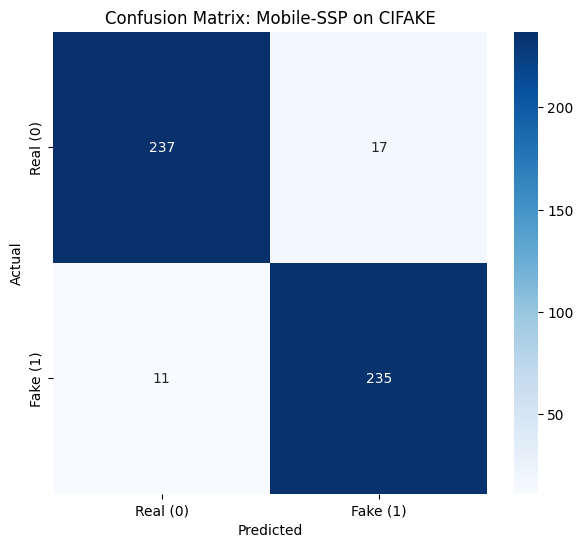

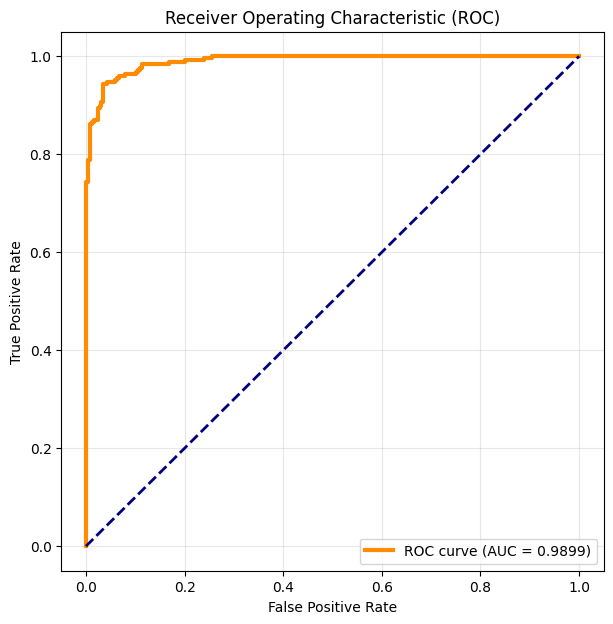

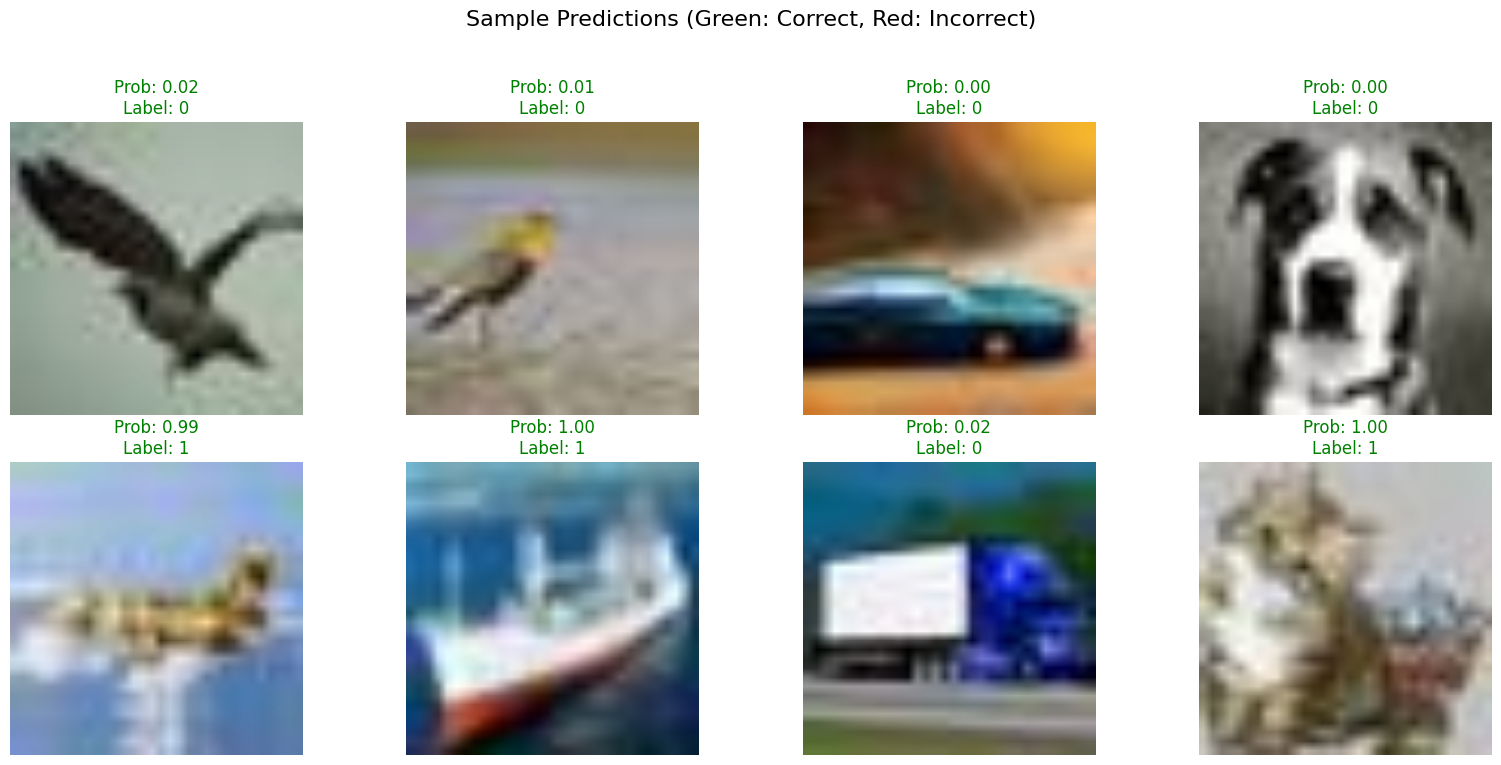


 FINAL CLASSIFICATION REPORT (CIFAKE)
              precision    recall  f1-score   support

        Real       0.96      0.93      0.94       254
        Fake       0.93      0.96      0.94       246

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500

 Train/Val Summary: Best Epoch was 4
 Best Validation Accuracy: 0.9420
 Final Test Accuracy: 0.9440
 AUC Score: 0.9899


In [ ]:

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import os

def final_evaluation(model_path, test_loader, device):

    model = ssp().to(device)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Successfully loaded best Mobile-SSP weights from {model_path}")
    else:
        print(f"Error: {model_path} not found! Ensure training finished correctly.")
        return

    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    print(" Running inference on final unbiased test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)


    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real (0)', 'Fake (1)'],
                yticklabels=['Real (0)', 'Fake (1)'])
    plt.title('Confusion Matrix: Mobile-SSP on CIFAKE')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('cifake_confusion_matrix.png')
    plt.show()

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig('cifake_roc_curve.png')
    plt.show()


    plt.figure(figsize=(16, 8))

    images, labels = next(iter(test_loader))
    with torch.no_grad():
        sample_outputs = model(images[:8].to(device))
        sample_probs = torch.sigmoid(sample_outputs).cpu().numpy()

    for i in range(8):
        plt.subplot(2, 4, i+1)
        img = images[i].permute(1, 2, 0).numpy()

        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = np.clip(img, 0, 1)
        plt.imshow(img)

        is_correct = (sample_probs[i] > 0.5) == labels[i]
        color = 'green' if is_correct else 'red'
        plt.title(f"Prob: {sample_probs[i]:.2f}\nLabel: {int(labels[i])}", color=color)
        plt.axis('off')

    plt.suptitle("Sample Predictions (Green: Correct, Red: Incorrect)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('sample_results.png')
    plt.show()

    print("\n" + "="*50)
    print(" FINAL CLASSIFICATION REPORT (CIFAKE)")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))
    print(f" Train/Val Summary: Best Epoch was {best_epoch}")
    print(f" Best Validation Accuracy: {best_accu:.4f}")
    print(f" Final Test Accuracy: {(all_labels == all_preds).mean():.4f}")
    print(f" AUC Score: {roc_auc:.4f}")
    print("="*50)

final_evaluation(
    model_path=os.path.join(opt.save_path, 'Net_epoch_best.pth'),
    test_loader=final_test_loader,
    device=DEVICE
)